<a href="https://colab.research.google.com/github/sarkarshrayan2-max/surface-scan-mlops/blob/main/notebooks/02_baseline_cnn_mlflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import os
import subprocess
PROJECT_ROOT = Path("/content/surface-scan-mlops")
if not PROJECT_ROOT.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/sarkarshrayan2-max/surface-scan-mlops.git",
        ],
        check=True,
    )
os.chdir(PROJECT_ROOT)
print("Current folder:", Path.cwd())
print("Project exists:", PROJECT_ROOT.exists())

Current folder: /content/surface-scan-mlops
Project exists: True


In [2]:
!pip -q install "mlflow>=3.0,<4.0" "cryptography>=49,<50"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264

In [3]:
from pathlib import Path

import mlflow
import mlflow.tensorflow
ARTIFACT_ROOT = Path("/content/mlartifacts")
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri("sqlite:////content/mlflow.db")
experiment_name = "surface-defect-classification"
experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment is None:
    mlflow.create_experiment(
        experiment_name,
        artifact_location=ARTIFACT_ROOT.as_uri(),
    )
mlflow.set_experiment(experiment_name)
mlflow.tensorflow.autolog(
    log_models=True,
    log_datasets=False,
)
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", experiment_name)
print("Artifact folder:", ARTIFACT_ROOT)

2026/07/07 20:01:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 20:01:29 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

Tracking URI: sqlite:////content/mlflow.db
Experiment: surface-defect-classification
Artifact folder: /content/mlartifacts


In [4]:
import mlflow
import tensorflow as tf

print("MLflow:", mlflow.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

MLflow: 3.2.0
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
mlflow.tensorflow.autolog(disable=True)

print("TensorFlow autologging disabled.")
print("We will log parameters, metrics, plots, and models manually.")

TensorFlow autologging disabled.
We will log parameters, metrics, plots, and models manually.


In [7]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!find "/content/drive/MyDrive/surface-scan-mlops/data_understanding" -maxdepth 3 -type f | sort

/content/drive/MyDrive/surface-scan-mlops/data_understanding/interim/excluded_duplicates.csv
/content/drive/MyDrive/surface-scan-mlops/data_understanding/interim/splits/test.csv
/content/drive/MyDrive/surface-scan-mlops/data_understanding/interim/splits/train.csv
/content/drive/MyDrive/surface-scan-mlops/data_understanding/interim/splits/validation.csv
/content/drive/MyDrive/surface-scan-mlops/data_understanding/reports/data_understanding/class_distribution.csv
/content/drive/MyDrive/surface-scan-mlops/data_understanding/reports/data_understanding/dataset_summary.json
/content/drive/MyDrive/surface-scan-mlops/data_understanding/reports/figures/class_distribution.png
/content/drive/MyDrive/surface-scan-mlops/data_understanding/reports/figures/sample_defect_images.png


In [10]:
!mkdir -p data/interim

!cp -r \
  "/content/drive/MyDrive/surface-scan-mlops/data_understanding/interim/"* \
  "data/interim/"

In [11]:
!find data/interim -maxdepth 3 -type f | sort

data/interim/excluded_duplicates.csv
data/interim/splits/test.csv
data/interim/splits/train.csv
data/interim/splits/validation.csv


In [12]:
!test -f ~/.kaggle/kaggle.json && echo "Kaggle credential found" || echo "Kaggle credential missing"

Kaggle credential missing


In [14]:
from google.colab import files

uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving kaggle (3).json to kaggle (3).json
Uploaded: ['kaggle (3).json']


In [15]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

uploaded_filename = next(iter(uploaded))

with open("/root/.kaggle/kaggle.json", "wb") as file:
    file.write(uploaded[uploaded_filename])

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle credential configured.")

Kaggle credential configured.


In [16]:
from pathlib import Path

required_paths = [
    Path("data/raw/NEU-DET/train/images"),
    Path("data/raw/NEU-DET/validation/images"),
    Path("data/interim/splits/train.csv"),
    Path("data/interim/splits/validation.csv"),
    Path("data/interim/splits/test.csv"),
]

for path in required_paths:
    print(f"{path}: {'FOUND' if path.exists() else 'MISSING'}")

data/raw/NEU-DET/train/images: MISSING
data/raw/NEU-DET/validation/images: MISSING
data/interim/splits/train.csv: FOUND
data/interim/splits/validation.csv: FOUND
data/interim/splits/test.csv: FOUND


In [17]:
!kaggle datasets download \
  -d kaustubhdikshit/neu-surface-defect-database \
  -p data/raw \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:00<00:00, 151MB/s] 



In [18]:
!unzip -q -o data/raw/neu-surface-defect-database.zip -d data/raw

unzip:  cannot find or open data/raw/neu-surface-defect-database.zip, data/raw/neu-surface-defect-database.zip.zip or data/raw/neu-surface-defect-database.zip.ZIP.


In [19]:
!find data/raw -maxdepth 3 -type d | sort

data/raw
data/raw/NEU-DET
data/raw/NEU-DET/train
data/raw/NEU-DET/train/annotations
data/raw/NEU-DET/train/images
data/raw/NEU-DET/validation
data/raw/NEU-DET/validation/annotations
data/raw/NEU-DET/validation/images


In [20]:

required_paths = [
    Path("data/raw/NEU-DET/train/images"),
    Path("data/raw/NEU-DET/validation/images"),
    Path("data/interim/splits/train.csv"),
    Path("data/interim/splits/validation.csv"),
    Path("data/interim/splits/test.csv"),
]

for path in required_paths:
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{path}: {status}")

data/raw/NEU-DET/train/images: FOUND
data/raw/NEU-DET/validation/images: FOUND
data/interim/splits/train.csv: FOUND
data/interim/splits/validation.csv: FOUND
data/interim/splits/test.csv: FOUND


In [21]:
import pandas as pd

split_dir = Path("data/interim/splits")

train_df = pd.read_csv(split_dir / "train.csv")
validation_df = pd.read_csv(split_dir / "validation.csv")
test_df = pd.read_csv(split_dir / "test.csv")

class_names = sorted(train_df["label"].unique())
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("Classes:", class_names)
print("Class mapping:", class_to_index)
print("\nTrain images:", len(train_df))
print("Validation images:", len(validation_df))
print("Test images:", len(test_df))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}

Train images: 1223
Validation images: 216
Test images: 360


In [22]:
import tensorflow as tf

IMAGE_SIZE = (200, 200)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

def load_and_preprocess_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image_bytes, channels=3)

    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


def make_dataset(dataframe, training=False):
    image_paths = dataframe["path"].astype(str).to_numpy()
    labels = dataframe["label"].map(class_to_index).to_numpy(dtype="int32")

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE,
    )

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, training=True)
validation_ds = make_dataset(validation_df)
test_ds = make_dataset(test_df)
images, labels = next(iter(train_ds))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 200, 200, 3)
Label batch shape: (32,)
First 10 labels: [5 4 0 4 5 0 0 5 0 2]


In [23]:
tf.keras.backend.clear_session()

NUM_CLASSES = len(class_names)
LEARNING_RATE = 0.001

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(0.08, seed=SEED),
        tf.keras.layers.RandomZoom(0.10, seed=SEED),
        tf.keras.layers.RandomContrast(0.10, seed=SEED),
    ],
    name="data_augmentation",
)

baseline_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(200, 200, 3)),
        data_augmentation,

        tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.30),

        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="custom_cnn_baseline",
)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

baseline_model.summary()

Model: "custom_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
from pathlib import Path

EPOCHS = 30
PATIENCE = 5
RUN_NAME = "custom-cnn-lr-0.001-dropout-0.40"

artifact_dir = Path("artifacts/baseline_cnn")
artifact_dir.mkdir(parents=True, exist_ok=True)

best_model_path = artifact_dir / "best_model.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Run name:", RUN_NAME)
print("Best model will be saved at:", best_model_path)
print("Epoch limit:", EPOCHS)
print("Early stopping patience:", PATIENCE)

Run name: custom-cnn-lr-0.001-dropout-0.40
Best model will be saved at: artifacts/baseline_cnn/best_model.keras
Epoch limit: 30
Early stopping patience: 5


In [25]:
import numpy as np
import mlflow

with mlflow.start_run(run_name=RUN_NAME) as run:
    mlflow.log_params(
        {
            "model_name": "custom_cnn_baseline",
            "image_height": IMAGE_SIZE[0],
            "image_width": IMAGE_SIZE[1],
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "epochs_limit": EPOCHS,
            "early_stopping_patience": PATIENCE,
            "dropout_conv_head": 0.40,
            "dropout_dense_head": 0.30,
            "optimizer": "Adam",
            "train_images": len(train_df),
            "validation_images": len(validation_df),
            "num_classes": NUM_CLASSES,
        }
    )

    history = baseline_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    for epoch_index in range(len(history.history["loss"])):
        mlflow.log_metrics(
            {
                "train_loss": float(history.history["loss"][epoch_index]),
                "train_accuracy": float(history.history["accuracy"][epoch_index]),
                "val_loss": float(history.history["val_loss"][epoch_index]),
                "val_accuracy": float(history.history["val_accuracy"][epoch_index]),
            },
            step=epoch_index + 1,
        )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    mlflow.log_metrics(
        {
            "best_epoch": best_epoch,
            "best_val_loss": float(min(history.history["val_loss"])),
            "best_val_accuracy": float(max(history.history["val_accuracy"])),
        }
    )

    mlflow.log_artifact(
        str(best_model_path),
        artifact_path="keras_model",
    )

    run_id = run.info.run_id

print("Training completed.")
print("MLflow run ID:", run_id)
print("Best model saved at:", best_model_path)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5913 - loss: 1.1406
Epoch 1: val_loss improved from None to 2.48843, saving model to artifacts/baseline_cnn/best_model.keras

Epoch 1: finished saving model to artifacts/baseline_cnn/best_model.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 127ms/step - accuracy: 0.6852 - loss: 0.8754 - val_accuracy: 0.2778 - val_loss: 2.4884 - learning_rate: 0.0010
Epoch 2/30
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7721 - loss: 0.6047
Epoch 2: val_loss did not improve from 2.48843
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.7809 - loss: 0.5728 - val_accuracy: 0.2639 - val_loss: 3.7808 - learning_rate: 0.0010
Epoch 3/30
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7972 - loss: 0.5631
Epoch 3: val_loss did not improve from 2.48843

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8054 - loss: 0.5496 - val_accuracy: 0.1667 - val_loss

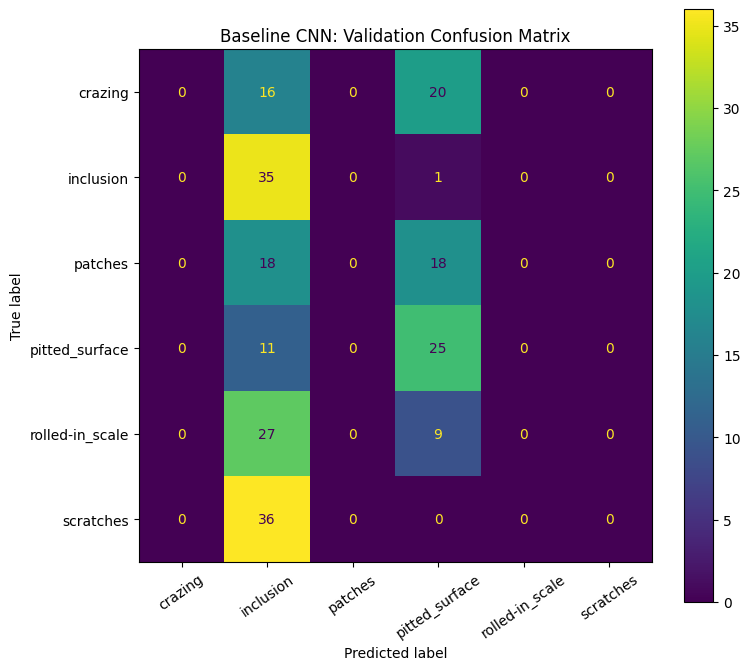

Validation metrics:
validation_accuracy: 0.2778
validation_macro_precision: 0.0979
validation_macro_recall: 0.2778
validation_macro_f1: 0.1416

Saved reports in: reports/baseline_cnn
Metrics added to MLflow run: 838171caf9c24245b6c9927f47eff598


In [26]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Predict only on the validation split
validation_probabilities = baseline_model.predict(validation_ds, verbose=0)
y_pred = np.argmax(validation_probabilities, axis=1)

y_true = np.concatenate(
    [batch_labels.numpy() for _, batch_labels in validation_ds],
    axis=0,
)

# Calculate validation metrics
validation_accuracy = accuracy_score(y_true, y_pred)
validation_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)
validation_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)
validation_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

# Save reports
report_dir = Path("reports/baseline_cnn")
report_dir.mkdir(parents=True, exist_ok=True)

metrics = {
    "validation_accuracy": float(validation_accuracy),
    "validation_macro_precision": float(validation_precision),
    "validation_macro_recall": float(validation_recall),
    "validation_macro_f1": float(validation_macro_f1),
}

with open(report_dir / "validation_metrics.json", "w") as file:
    json.dump(metrics, file, indent=2)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

with open(report_dir / "classification_report.json", "w") as file:
    json.dump(report, file, indent=2)

# Save confusion matrix figure
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    xticks_rotation=35,
    ax=ax,
)

plt.title("Baseline CNN: Validation Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = report_dir / "validation_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=160)
plt.show()

# Add evaluation results to the same MLflow run
with mlflow.start_run(run_id=run_id):
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(
        str(report_dir / "validation_metrics.json"),
        artifact_path="evaluation",
    )
    mlflow.log_artifact(
        str(report_dir / "classification_report.json"),
        artifact_path="evaluation",
    )
    mlflow.log_artifact(
        str(confusion_matrix_path),
        artifact_path="evaluation",
    )

print("Validation metrics:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\nSaved reports in:", report_dir)
print("Metrics added to MLflow run:", run_id)

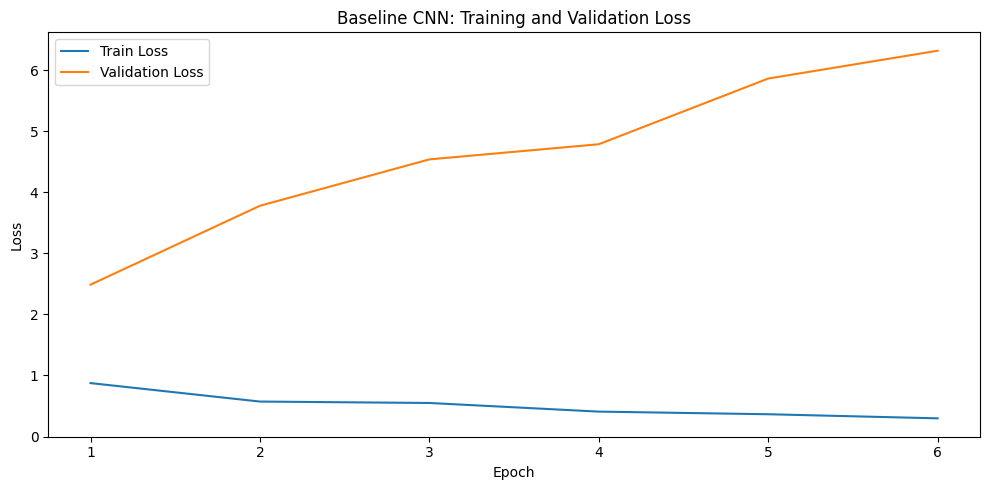

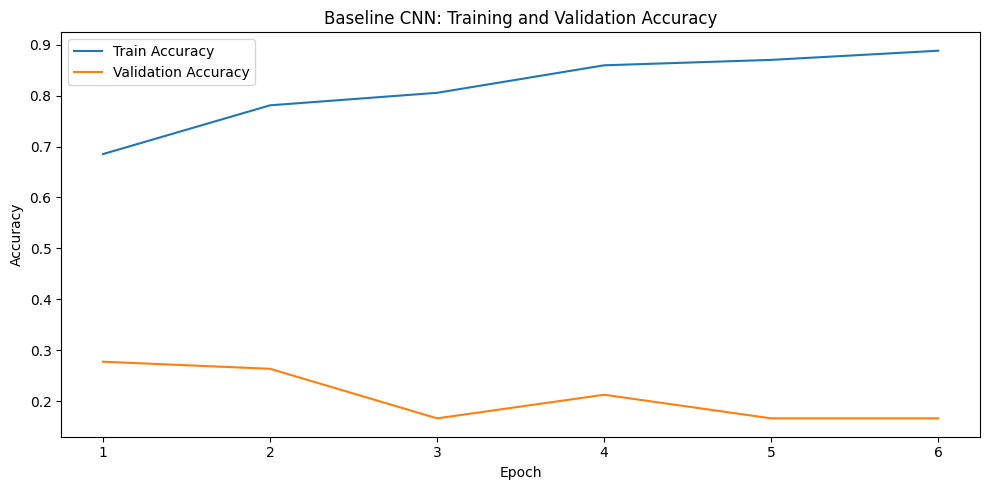

Training curves saved and logged to MLflow.


In [27]:
from pathlib import Path

import matplotlib.pyplot as plt

report_dir = Path("reports/baseline_cnn")
report_dir.mkdir(parents=True, exist_ok=True)

epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history.history["loss"], label="Train Loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training and Validation Loss")
plt.legend()
plt.tight_layout()

loss_curve_path = report_dir / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=160)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history.history["accuracy"], label="Train Accuracy")
plt.plot(epochs_ran, history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()

accuracy_curve_path = report_dir / "accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=160)
plt.show()

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(str(loss_curve_path), artifact_path="training_curves")
    mlflow.log_artifact(str(accuracy_curve_path), artifact_path="training_curves")

print("Training curves saved and logged to MLflow.")

In [28]:
import subprocess
import time

mlflow_server = subprocess.Popen(
    [
        "mlflow",
        "server",
        "--backend-store-uri",
        "sqlite:////content/mlflow.db",
        "--host",
        "0.0.0.0",
        "--port",
        "5000",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

time.sleep(5)

print("MLflow server started on port 5000.")
print("Process ID:", mlflow_server.pid)

MLflow server started on port 5000.
Process ID: 17708


In [29]:
from google.colab import output
from IPython.display import display, HTML

mlflow_url = output.eval_js("google.colab.kernel.proxyPort(5000)")

display(
    HTML(
        f'<a href="{mlflow_url}" target="_blank">'
        f'Open MLflow Dashboard</a>'
    )
)

print(mlflow_url)

https://5000-gpu-t4-s-kkb-usw1b1-20ph7q3p87qdc-b.us-west1-1.prod.colab.dev


In [30]:
tf.keras.backend.clear_session()

LEARNING_RATE_2 = 0.0001
RUN_NAME_2 = "custom-cnn-lr-0.0001-dropout-0.50"

print("Next MLflow run:", RUN_NAME_2)
print("Learning rate:", LEARNING_RATE_2)

Next MLflow run: custom-cnn-lr-0.0001-dropout-0.50
Learning rate: 0.0001


In [31]:
from pathlib import Path
import tensorflow as tf

tf.keras.backend.clear_session()

REGULARIZER = tf.keras.regularizers.l2(1e-4)

augmentation_2 = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal_and_vertical",
            seed=SEED,
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED,
        ),
    ],
    name="mild_augmentation",
)

baseline_model_2 = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(200, 200, 3)),
        augmentation_2,

        tf.keras.layers.Conv2D(
            32,
            3,
            padding="same",
            activation="relu",
            kernel_regularizer=REGULARIZER,
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            64,
            3,
            padding="same",
            activation="relu",
            kernel_regularizer=REGULARIZER,
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            128,
            3,
            padding="same",
            activation="relu",
            kernel_regularizer=REGULARIZER,
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.50),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=REGULARIZER,
        ),
        tf.keras.layers.Dropout(0.30),

        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="custom_cnn_regularized",
)

baseline_model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_2),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

artifact_dir_2 = Path("artifacts/baseline_cnn_regularized")
artifact_dir_2.mkdir(parents=True, exist_ok=True)

best_model_path_2 = artifact_dir_2 / "best_model.keras"

callbacks_2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path_2,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

baseline_model_2.summary()

Model: "custom_cnn_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mild_augmentation (Sequential)  │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,790 (401.52 KB)

 Trainable params: 102,342 (399.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [32]:
import mlflow
import numpy as np

with mlflow.start_run(run_name=RUN_NAME_2) as run:
    run_id_2 = run.info.run_id

    mlflow.log_params(
        {
            "model_name": "custom_cnn_regularized",
            "image_height": IMAGE_SIZE[0],
            "image_width": IMAGE_SIZE[1],
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE_2,
            "epochs_limit": EPOCHS,
            "early_stopping_patience": 6,
            "dropout_conv_head": 0.50,
            "dropout_dense_head": 0.30,
            "l2_regularization": 1e-4,
            "optimizer": "Adam",
            "train_images": len(train_df),
            "validation_images": len(validation_df),
            "num_classes": NUM_CLASSES,
        }
    )

    history_2 = baseline_model_2.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=EPOCHS,
        callbacks=callbacks_2,
        verbose=1,
    )

    for epoch_index in range(len(history_2.history["loss"])):
        mlflow.log_metrics(
            {
                "train_loss": float(history_2.history["loss"][epoch_index]),
                "train_accuracy": float(history_2.history["accuracy"][epoch_index]),
                "val_loss": float(history_2.history["val_loss"][epoch_index]),
                "val_accuracy": float(history_2.history["val_accuracy"][epoch_index]),
            },
            step=epoch_index + 1,
        )

    best_epoch_index = int(np.argmin(history_2.history["val_loss"]))
    best_epoch = best_epoch_index + 1

    mlflow.log_metrics(
        {
            "best_epoch": best_epoch,
            "best_val_loss": float(history_2.history["val_loss"][best_epoch_index]),
            "best_val_accuracy": float(
                history_2.history["val_accuracy"][best_epoch_index]
            ),
        }
    )

    mlflow.log_artifact(
        str(best_model_path_2),
        artifact_path="keras_model",
    )

print("Training completed.")
print("MLflow run ID:", run_id_2)
print("Best model saved at:", best_model_path_2)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.2834 - loss: 1.9018
Epoch 1: val_loss improved from None to 1.79428, saving model to artifacts/baseline_cnn_regularized/best_model.keras

Epoch 1: finished saving model to artifacts/baseline_cnn_regularized/best_model.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.3737 - loss: 1.6686 - val_accuracy: 0.2407 - val_loss: 1.7943 - learning_rate: 1.0000e-04
Epoch 2/30
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5130 - loss: 1.3088
Epoch 2: val_loss improved from 1.79428 to 1.78102, saving model to artifacts/baseline_cnn_regularized/best_model.keras

Epoch 2: finished saving model to artifacts/baseline_cnn_regularized/best_model.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.5356 - loss: 1.2285 - val_accuracy: 0.2639 - val_loss: 1.7810 - learning_rate: 1.0000e-04
Epoch 3/30
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6169 - loss: 1.0204
Epoch 3: val_loss improved from 1.78102 

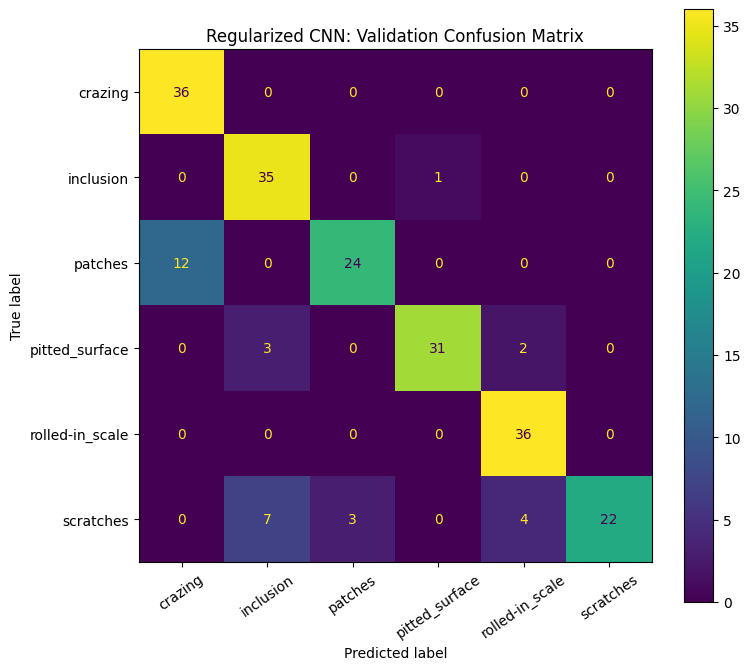

Validation metrics:
validation_accuracy: 0.8519
validation_macro_precision: 0.8738
validation_macro_recall: 0.8519
validation_macro_f1: 0.8461

Logged to MLflow run: 90f1e774dd8d465ea90e39897b673bb2


In [33]:
validation_probabilities_2 = baseline_model_2.predict(validation_ds, verbose=0)
y_pred_2 = np.argmax(validation_probabilities_2, axis=1)

y_true_2 = np.concatenate(
    [batch_labels.numpy() for _, batch_labels in validation_ds],
    axis=0,
)

metrics_2 = {
    "validation_accuracy": float(accuracy_score(y_true_2, y_pred_2)),
    "validation_macro_precision": float(
        precision_score(y_true_2, y_pred_2, average="macro", zero_division=0)
    ),
    "validation_macro_recall": float(
        recall_score(y_true_2, y_pred_2, average="macro", zero_division=0)
    ),
    "validation_macro_f1": float(
        f1_score(y_true_2, y_pred_2, average="macro", zero_division=0)
    ),
}

report_dir_2 = Path("reports/baseline_cnn_regularized")
report_dir_2.mkdir(parents=True, exist_ok=True)

with open(report_dir_2 / "validation_metrics.json", "w") as file:
    json.dump(metrics_2, file, indent=2)

classification_report_2 = classification_report(
    y_true_2,
    y_pred_2,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

with open(report_dir_2 / "classification_report.json", "w") as file:
    json.dump(classification_report_2, file, indent=2)

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_true_2,
    y_pred_2,
    display_labels=class_names,
    xticks_rotation=35,
    ax=ax,
)

plt.title("Regularized CNN: Validation Confusion Matrix")
plt.tight_layout()

confusion_matrix_path_2 = report_dir_2 / "validation_confusion_matrix.png"
plt.savefig(confusion_matrix_path_2, dpi=160)
plt.show()

with mlflow.start_run(run_id=run_id_2):
    mlflow.log_metrics(metrics_2)
    mlflow.log_artifact(
        str(report_dir_2 / "validation_metrics.json"),
        artifact_path="evaluation",
    )
    mlflow.log_artifact(
        str(report_dir_2 / "classification_report.json"),
        artifact_path="evaluation",
    )
    mlflow.log_artifact(
        str(confusion_matrix_path_2),
        artifact_path="evaluation",
    )

print("Validation metrics:")
for metric_name, metric_value in metrics_2.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\nLogged to MLflow run:", run_id_2)

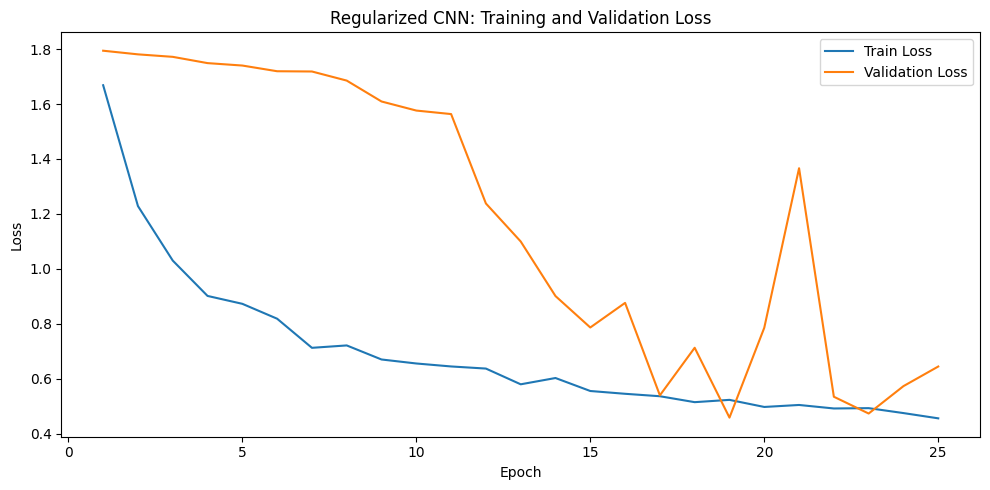

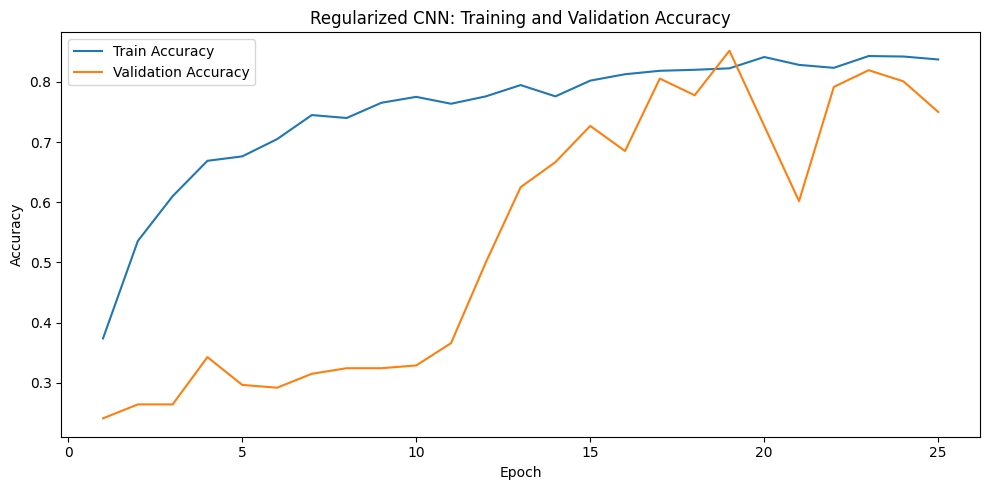

Run 2 training curves saved and logged to MLflow.


In [34]:
from pathlib import Path
import matplotlib.pyplot as plt

report_dir_2 = Path("reports/baseline_cnn_regularized")
report_dir_2.mkdir(parents=True, exist_ok=True)

epochs_ran_2 = range(1, len(history_2.history["loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran_2, history_2.history["loss"], label="Train Loss")
plt.plot(epochs_ran_2, history_2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Regularized CNN: Training and Validation Loss")
plt.legend()
plt.tight_layout()

loss_curve_path_2 = report_dir_2 / "loss_curve.png"
plt.savefig(loss_curve_path_2, dpi=160)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran_2, history_2.history["accuracy"], label="Train Accuracy")
plt.plot(epochs_ran_2, history_2.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Regularized CNN: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()

accuracy_curve_path_2 = report_dir_2 / "accuracy_curve.png"
plt.savefig(accuracy_curve_path_2, dpi=160)
plt.show()

with mlflow.start_run(run_id=run_id_2):
    mlflow.log_artifact(str(loss_curve_path_2), artifact_path="training_curves")
    mlflow.log_artifact(str(accuracy_curve_path_2), artifact_path="training_curves")

print("Run 2 training curves saved and logged to MLflow.")

In [35]:
import pandas as pd
import mlflow

experiment = mlflow.get_experiment_by_name(
    "surface-defect-classification"
)

runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    output_format="pandas",
)

comparison = runs_df[
    [
        "tags.mlflow.runName",
        "params.model_name",
        "params.learning_rate",
        "metrics.validation_accuracy",
        "metrics.validation_macro_precision",
        "metrics.validation_macro_recall",
        "metrics.validation_macro_f1",
        "metrics.best_epoch",
    ]
].copy()

comparison = comparison.sort_values(
    by="metrics.validation_macro_f1",
    ascending=False,
)

comparison = comparison.rename(
    columns={
        "tags.mlflow.runName": "run_name",
        "params.model_name": "model",
        "params.learning_rate": "learning_rate",
        "metrics.validation_accuracy": "validation_accuracy",
        "metrics.validation_macro_precision": "macro_precision",
        "metrics.validation_macro_recall": "macro_recall",
        "metrics.validation_macro_f1": "macro_f1",
        "metrics.best_epoch": "best_epoch",
    }
)

comparison = comparison.reset_index(drop=True)

comparison_path = "reports/baseline_cnn_comparison.csv"
comparison.to_csv(comparison_path, index=False)

comparison

,run_name,model,learning_rate,validation_accuracy,macro_precision,macro_recall,macro_f1,best_epoch
0,custom-cnn-lr-0.0001-dropout-0.50,custom_cnn_regularized,0.0001,0.851852,0.87376,0.851852,0.846118,19.0
1,custom-cnn-lr-0.001-dropout-0.40,custom_cnn_baseline,0.001,0.277778,0.09787,0.277778,0.141630,1.0


In [36]:
from pathlib import Path
import shutil

backup_root = Path(
    "/content/drive/MyDrive/surface-scan-mlops/baseline_cnn"
)
backup_root.mkdir(parents=True, exist_ok=True)

items_to_backup = [
    Path("/content/mlflow.db"),
    Path("/content/mlartifacts"),
    Path("artifacts"),
    Path("reports"),
]

for source in items_to_backup:
    if not source.exists():
        print(f"Skipped missing: {source}")
        continue

    destination = backup_root / source.name

    if destination.exists():
        if destination.is_dir():
            shutil.rmtree(destination)
        else:
            destination.unlink()

    if source.is_dir():
        shutil.copytree(source, destination)
    else:
        shutil.copy2(source, destination)

    print(f"Backed up: {source} → {destination}")

print("\nBackup complete.")

Backed up: /content/mlflow.db → /content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlflow.db
Backed up: /content/mlartifacts → /content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlartifacts
Backed up: artifacts → /content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts
Backed up: reports → /content/drive/MyDrive/surface-scan-mlops/baseline_cnn/reports

Backup complete.
